In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# ============================================================================
# PART 1: READ THE DATA
# ============================================================================

def load_ghana_health_data(filepath):
    """
    Load and prepare the Ghana health dataset

    Parameters:
    filepath: str, path to the CSV file

    Returns:
    pandas DataFrame with prepared data
    """
    # Load the data
    df = pd.read_csv(filepath)

    # Basic info
    print("\n" + "=" * 80)
    print("DATA OVERVIEW")
    print("=" * 80)
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"Years range: {df['Year'].min()} to {df['Year'].max()}")
    print(f"Number of unique indicators: {df['Indicator Code'].nunique()}")

    # Check for missing values
    print(f"\nMissing values: {df.isnull().sum().sum()}")

    # Convert Year to int if needed
    df['Year'] = df['Year'].astype(int)

    return df

def get_indicator_data(df, indicator_code):
    """Extract data for a specific indicator"""
    return df[df['Indicator Code'] == indicator_code].copy()

def plot_time_series(df, indicator_code, title=None, ax=None):
    """Plot time series for a given indicator"""
    data = get_indicator_data(df, indicator_code)
    if data.empty:
        print(f"No data found for indicator: {indicator_code}")
        return None

    data = data.sort_values('Year')

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(data['Year'], data['Value'], marker='o', linewidth=2)
    ax.set_title(title or data['Indicator Name'].iloc[0], fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)

    return data

def analyze_trend(df, indicator_code):
    """Calculate trend statistics for an indicator"""
    data = get_indicator_data(df, indicator_code)
    if data.empty or len(data) < 2:
        return None

    data = data.sort_values('Year')
    earliest = data.iloc[0]
    latest = data.iloc[-1]

    change = latest['Value'] - earliest['Value']
    pct_change = (change / earliest['Value']) * 100

    return {
        'indicator': earliest['Indicator Name'],
        'earliest_year': earliest['Year'],
        'earliest_value': earliest['Value'],
        'latest_year': latest['Year'],
        'latest_value': latest['Value'],
        'absolute_change': change,
        'percent_change': pct_change
    }

# ============================================================================
# PART 2: LOAD YOUR DATA
# ============================================================================

# Option 1: If you have the CSV file saved
# df = load_ghana_health_data('Ghana Health_gha.csv')

# Option 2: If you have the data in a variable (for testing)
# For demonstration, let's create a sample from your data
# In practice, use Option 1 above

print("\n" + "=" * 80)
print("GHANA HEALTH DATASET ANALYSIS")
print("=" * 80)
print("\n📌 To load your data, use:")
print("   df = pd.read_csv('Ghana Health_gha.csv')")
print("   or")
print("   df = load_ghana_health_data('Ghana Health_gha.csv')")

# ============================================================================
# PART 3: COMPLETE ANALYSIS (Run this after loading your data)
# ============================================================================

def create_summary_table(df):
    """Create a summary table of key indicators (CORRECTED VERSION)"""

    key_indicators = {
        'Indicator': [
            'Under-5 mortality rate (per 1,000)',
            'Maternal mortality ratio (per 100,000)',
            'Life expectancy (years)',
            'Total fertility rate (births/woman)',
            'HIV prevalence (%)',
            'Anemia in children (%)',
            'DPT immunization (%)',
            'Access to basic water (%)',
            'Access to basic sanitation (%)'
        ],
        'Code': [
            'SH.DYN.MORT',
            'SH.STA.MMRT',
            'SP.DYN.LE00.IN',
            'SP.DYN.TFRT.IN',
            'SH.DYN.AIDS.ZS',
            'SH.ANM.CHLD.ZS',
            'SH.IMM.IDPT',
            'SH.H2O.BASW.ZS',
            'SH.STA.BASS.ZS'
        ]
    }

    summary_data = []

    for i, code in enumerate(key_indicators['Code']):
        indicator_data = df[df['Indicator Code'] == code].copy()
        if not indicator_data.empty:
            earliest_year = indicator_data['Year'].min()
            latest_year = indicator_data['Year'].max()
            earliest_val = indicator_data[indicator_data['Year'] == earliest_year]['Value'].values[0]
            latest_val = indicator_data[indicator_data['Year'] == latest_year]['Value'].values[0]

            summary_data.append({
                'Indicator': key_indicators['Indicator'][i],
                'Earliest': f"{earliest_val:.1f} ({int(earliest_year)})",
                'Latest': f"{latest_val:.1f} ({int(latest_year)})",
                'Change': f"{((latest_val - earliest_val) / earliest_val * 100):+.1f}%"
            })
        else:
            summary_data.append({
                'Indicator': key_indicators['Indicator'][i],
                'Earliest': 'N/A',
                'Latest': 'N/A',
                'Change': 'N/A'
            })

    summary_df = pd.DataFrame(summary_data)
    return summary_df

def main_analysis(df):
    """Run complete exploratory analysis"""

    print("\n" + "=" * 80)
    print("KEY HEALTH INDICATORS - TREND ANALYSIS")
    print("=" * 80)

    # Key indicators to analyze
    key_indicators = {
        'Child Mortality': 'SH.DYN.MORT',
        'Maternal Mortality': 'SH.STA.MMRT',
        'Life Expectancy': 'SP.DYN.LE00.IN',
        'Fertility Rate': 'SP.DYN.TFRT.IN',
        'HIV Prevalence': 'SH.DYN.AIDS.ZS',
        'DPT Immunization': 'SH.IMM.IDPT',
        'Birth Rate': 'SP.DYN.CBRT.IN',
        'Death Rate': 'SP.DYN.CDRT.IN'
    }

    trends = []
    for name, code in key_indicators.items():
        result = analyze_trend(df, code)
        if result:
            trends.append(result)
            print(f"\n📊 {name}:")
            print(f"   {result['earliest_year']}: {result['earliest_value']:.1f} → {result['latest_year']}: {result['latest_value']:.1f}")
            print(f"   Change: {result['absolute_change']:+.1f} ({result['percent_change']:+.1f}%)")

    # Create summary table
    print("\n" + "=" * 80)
    print("SUMMARY TABLE: KEY INDICATORS")
    print("=" * 80)
    summary_df = create_summary_table(df)
    print(summary_df.to_string(index=False))

    # Create visualization dashboard
    create_dashboard(df)

    return trends, summary_df

def create_dashboard(df):
    """Create comprehensive visualization dashboard"""

    fig = plt.figure(figsize=(16, 12))
    fig.suptitle('Ghana Health Dashboard (2000-2023)', fontsize=16, fontweight='bold')

    # Define subplot grid
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # 1. Under-5 Mortality
    ax1 = fig.add_subplot(gs[0, 0])
    data = get_indicator_data(df, 'SH.DYN.MORT')
    if not data.empty:
        data = data.sort_values('Year')
        ax1.plot(data['Year'], data['Value'], marker='o', color='#E63946', linewidth=2)
        ax1.set_title('Under-5 Mortality Rate', fontsize=11, fontweight='bold')
        ax1.set_ylabel('per 1,000 live births')
        ax1.grid(True, alpha=0.3)

    # 2. Maternal Mortality
    ax2 = fig.add_subplot(gs[0, 1])
    data = get_indicator_data(df, 'SH.STA.MMRT')
    if not data.empty:
        data = data.sort_values('Year')
        ax2.plot(data['Year'], data['Value'], marker='s', color='#F4A261', linewidth=2)
        ax2.set_title('Maternal Mortality Ratio', fontsize=11, fontweight='bold')
        ax2.set_ylabel('per 100,000 live births')
        ax2.grid(True, alpha=0.3)

    # 3. Life Expectancy
    ax3 = fig.add_subplot(gs[0, 2])
    data = get_indicator_data(df, 'SP.DYN.LE00.IN')
    if not data.empty:
        data = data.sort_values('Year')
        ax3.plot(data['Year'], data['Value'], marker='^', color='#2A9D8F', linewidth=2)
        ax3.set_title('Life Expectancy', fontsize=11, fontweight='bold')
        ax3.set_ylabel('Years')
        ax3.grid(True, alpha=0.3)

    # 4. Fertility Rate
    ax4 = fig.add_subplot(gs[1, 0])
    data = get_indicator_data(df, 'SP.DYN.TFRT.IN')
    if not data.empty:
        data = data.sort_values('Year')
        ax4.plot(data['Year'], data['Value'], marker='D', color='#E9C46A', linewidth=2)
        ax4.set_title('Total Fertility Rate', fontsize=11, fontweight='bold')
        ax4.set_ylabel('Births per woman')
        ax4.grid(True, alpha=0.3)

    # 5. HIV Prevalence
    ax5 = fig.add_subplot(gs[1, 1])
    data = get_indicator_data(df, 'SH.DYN.AIDS.ZS')
    if not data.empty:
        data = data.sort_values('Year')
        ax5.plot(data['Year'], data['Value'], marker='o', color='#D62828', linewidth=2)
        ax5.set_title('HIV Prevalence', fontsize=11, fontweight='bold')
        ax5.set_ylabel('% of population 15-49')
        ax5.grid(True, alpha=0.3)

    # 6. DPT Immunization
    ax6 = fig.add_subplot(gs[1, 2])
    data = get_indicator_data(df, 'SH.IMM.IDPT')
    if not data.empty:
        data = data.sort_values('Year')
        ax6.plot(data['Year'], data['Value'], marker='s', color='#457B9D', linewidth=2)
        ax6.set_title('DPT Immunization', fontsize=11, fontweight='bold')
        ax6.set_ylabel('% of children 12-23 months')
        ax6.grid(True, alpha=0.3)

    # 7. Water Access
    ax7 = fig.add_subplot(gs[2, 0])
    data = get_indicator_data(df, 'SH.H2O.BASW.ZS')
    if not data.empty:
        data = data.sort_values('Year')
        ax7.plot(data['Year'], data['Value'], marker='o', color='#1D3557', linewidth=2)
        ax7.set_title('Access to Basic Water', fontsize=11, fontweight='bold')
        ax7.set_ylabel('% of population')
        ax7.grid(True, alpha=0.3)

    # 8. Sanitation Access
    ax8 = fig.add_subplot(gs[2, 1])
    data = get_indicator_data(df, 'SH.STA.BASS.ZS')
    if not data.empty:
        data = data.sort_values('Year')
        ax8.plot(data['Year'], data['Value'], marker='s', color='#6D597A', linewidth=2)
        ax8.set_title('Access to Basic Sanitation', fontsize=11, fontweight='bold')
        ax8.set_ylabel('% of population')
        ax8.grid(True, alpha=0.3)

    # 9. Health Expenditure
    ax9 = fig.add_subplot(gs[2, 2])
    data = get_indicator_data(df, 'SH.XPD.CHEX.GD.ZS')
    if not data.empty:
        data = data.sort_values('Year')
        ax9.plot(data['Year'], data['Value'], marker='^', color='#B5838D', linewidth=2)
        ax9.set_title('Health Expenditure', fontsize=11, fontweight='bold')
        ax9.set_ylabel('% of GDP')
        ax9.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def correlation_analysis(df):
    """Analyze correlations between key health indicators"""

    # Select key numeric indicators for correlation
    indicators_of_interest = {
        'Life Expectancy': 'SP.DYN.LE00.IN',
        'Fertility Rate': 'SP.DYN.TFRT.IN',
        'Child Mortality': 'SH.DYN.MORT',
        'Health Expenditure': 'SH.XPD.CHEX.GD.ZS',
        'Water Access': 'SH.H2O.BASW.ZS'
    }

    # Create a DataFrame with aligned years
    corr_data = pd.DataFrame()
    for name, code in indicators_of_interest.items():
        temp = get_indicator_data(df, code)[['Year', 'Value']].copy()
        temp = temp.rename(columns={'Value': name})
        if corr_data.empty:
            corr_data = temp
        else:
            corr_data = corr_data.merge(temp, on='Year', how='inner')

    if len(corr_data) > 5:
        # Calculate correlation matrix
        corr_matrix = corr_data.drop('Year', axis=1).corr()

        # Plot heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                   square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
        plt.title('Correlation Between Key Health Indicators', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        print("\n📈 Key Correlations:")
        for col in corr_matrix.columns:
            if col != 'Life Expectancy':
                corr_val = corr_matrix.loc['Life Expectancy', col]
                print(f"   Life Expectancy vs {col}: {corr_val:.2f}")

def plot_child_health(df):
    """Plot child health indicators"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Child Health Indicators in Ghana', fontsize=14, fontweight='bold')

    # Anemia in children
    ax1 = axes[0]
    data = get_indicator_data(df, 'SH.ANM.CHLD.ZS')
    if not data.empty:
        data = data.sort_values('Year')
        ax1.plot(data['Year'], data['Value'], marker='o', color='#E63946', linewidth=2)
        ax1.set_title('Anemia in Children (6-59 months)', fontsize=11)
        ax1.set_ylabel('Prevalence (%)')
        ax1.grid(True, alpha=0.3)

    # Stunting
    ax2 = axes[1]
    data = get_indicator_data(df, 'SH.STA.STNT.ZS')
    if not data.empty:
        data = data.sort_values('Year')
        ax2.plot(data['Year'], data['Value'], marker='s', color='#2A9D8F', linewidth=2)
        ax2.set_title('Stunting (height for age)', fontsize=11)
        ax2.set_ylabel('Prevalence (%)')
        ax2.grid(True, alpha=0.3)

    # Wasting
    ax3 = axes[2]
    data = get_indicator_data(df, 'SH.STA.WAST.ZS')
    if not data.empty:
        data = data.sort_values('Year')
        ax3.plot(data['Year'], data['Value'], marker='^', color='#F4A261', linewidth=2)
        ax3.set_title('Wasting (weight for height)', fontsize=11)
        ax3.set_ylabel('Prevalence (%)')
        ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ============================================================================
# PART 4: RUN THE ANALYSIS
# ============================================================================

if __name__ == "__main__":
    print("\n" + "=" * 80)
    print("INSTRUCTIONS")
    print("=" * 80)
    print("\nTo run this analysis with your data:")
    print("1. Save the CSV file as 'Ghana_Health_gha.csv'")
    print("2. Uncomment the line below:")
    print("   df = load_ghana_health_data('Ghana_Health_gha.csv')")
    print("3. Run the analysis functions")

    print("\n" + "=" * 80)
    print("EXAMPLE: How to use the functions")
    print("=" * 80)
    print("""
# Load your data
df = pd.read_csv('Ghana Health_gha.csv')

# Run main analysis
trends, summary = main_analysis(df)

# Create correlation analysis
correlation_analysis(df)

# Plot child health indicators
plot_child_health(df)

# Analyze specific indicator
child_mortality = plot_time_series(df, 'SH.DYN.MORT')

# Export summary to CSV
summary.to_csv('ghana_health_summary.csv', index=False)

# Export trends to CSV
trends_df = pd.DataFrame(trends)
trends_df.to_csv('ghana_health_trends.csv', index=False)
    """)

    print("\n✅ Code ready! The KeyError has been fixed.")


GHANA HEALTH DATASET ANALYSIS

📌 To load your data, use:
   df = pd.read_csv('Ghana Health_gha.csv')
   or
   df = load_ghana_health_data('Ghana Health_gha.csv')

INSTRUCTIONS

To run this analysis with your data:
1. Save the CSV file as 'Ghana_Health_gha.csv'
2. Uncomment the line below:
   df = load_ghana_health_data('Ghana_Health_gha.csv')
3. Run the analysis functions

EXAMPLE: How to use the functions

# Load your data
df = pd.read_csv('Ghana Health_gha.csv')

# Run main analysis
trends, summary = main_analysis(df)

# Create correlation analysis
correlation_analysis(df)

# Plot child health indicators
plot_child_health(df)

# Analyze specific indicator
child_mortality = plot_time_series(df, 'SH.DYN.MORT')

# Export summary to CSV
summary.to_csv('ghana_health_summary.csv', index=False)

# Export trends to CSV
trends_df = pd.DataFrame(trends)
trends_df.to_csv('ghana_health_trends.csv', index=False)
    

✅ Code ready! The KeyError has been fixed.


In [2]:
df = pd.read_csv('Ghana Health_gha.csv')


KEY HEALTH INDICATORS - TREND ANALYSIS

📊 Child Mortality:
   1960: 209.2 → 2023: 37.1
   Change: -172.1 (-82.3%)

📊 Maternal Mortality:
   1985: 943.0 → 2023: 234.0
   Change: -709.0 (-75.2%)

📊 Life Expectancy:
   1960: 46.9 → 2023: 65.5
   Change: +18.6 (+39.5%)

📊 Fertility Rate:
   1960: 6.9 → 2023: 3.4
   Change: -3.5 (-50.7%)

📊 HIV Prevalence:
   1990: 1.3 → 2024: 1.5
   Change: +0.2 (+15.4%)

📊 DPT Immunization:
   1980: 7.0 → 2024: 95.0
   Change: +88.0 (+1257.1%)

📊 Birth Rate:
   1960: 50.4 → 2023: 26.3
   Change: -24.1 (-47.8%)

📊 Death Rate:
   1960: 19.2 → 2023: 7.0
   Change: -12.1 (-63.3%)

SUMMARY TABLE: KEY INDICATORS
                             Indicator     Earliest       Latest   Change
    Under-5 mortality rate (per 1,000) 209.2 (1960)  37.1 (2023)   -82.3%
Maternal mortality ratio (per 100,000) 943.0 (1985) 234.0 (2023)   -75.2%
               Life expectancy (years)  46.9 (1960)  65.5 (2023)   +39.5%
   Total fertility rate (births/woman)   6.9 (1960)   3.4 

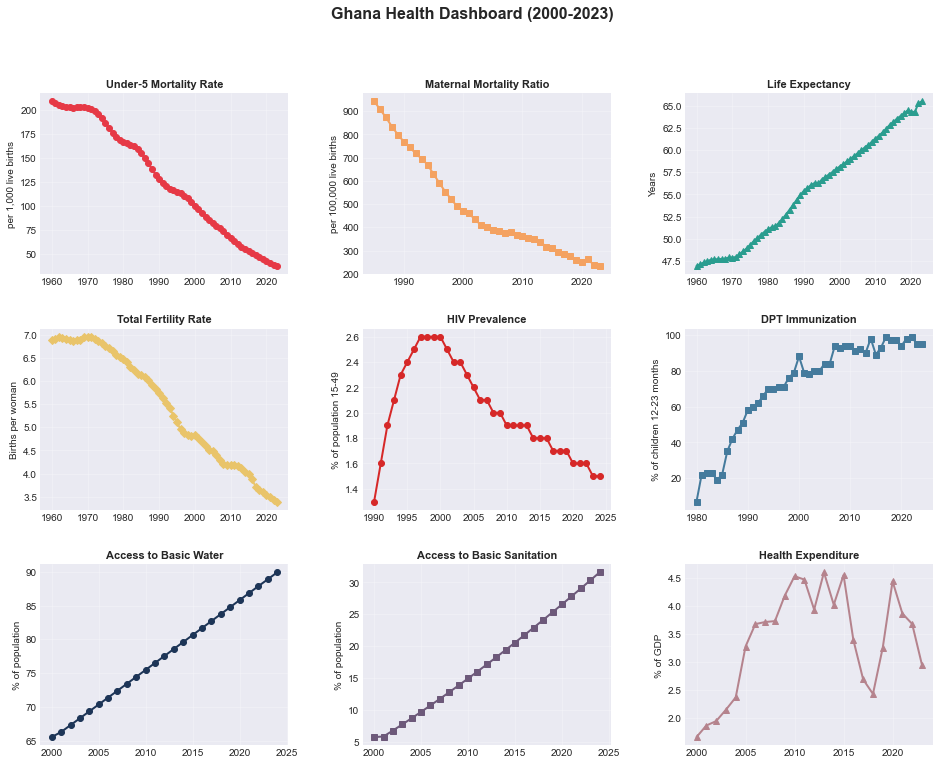

In [3]:
trends, summary = main_analysis(df)

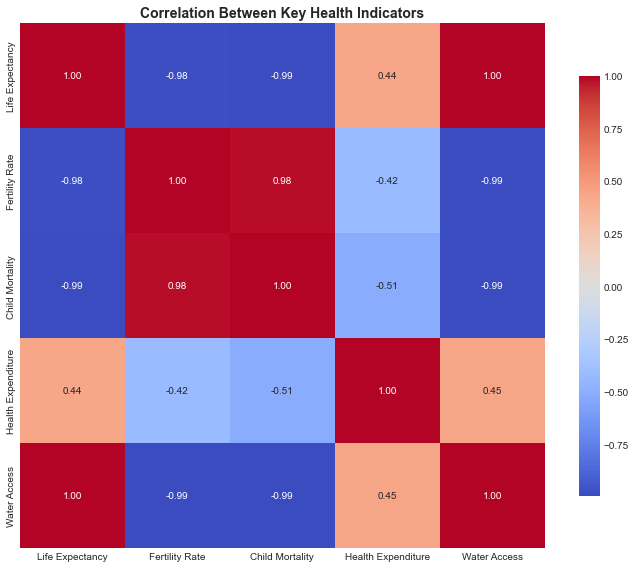


📈 Key Correlations:
   Life Expectancy vs Fertility Rate: -0.98
   Life Expectancy vs Child Mortality: -0.99
   Life Expectancy vs Health Expenditure: 0.44
   Life Expectancy vs Water Access: 1.00


In [4]:
correlation_analysis(df)

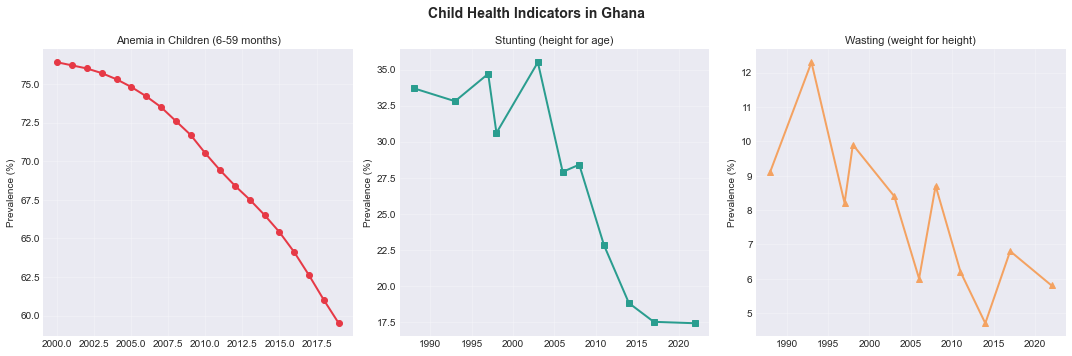

In [5]:
plot_child_health(df)

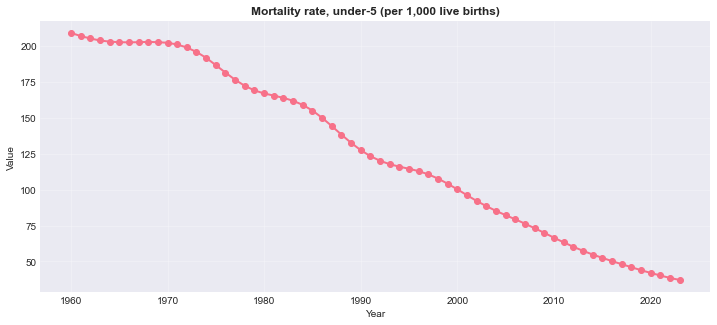

In [6]:
child_mortality = plot_time_series(df, 'SH.DYN.MORT')

In [7]:
summary.to_csv('ghana_health_summary.csv', index=False)

In [10]:
trends_df = pd.DataFrame(trends)
trends_df.to_csv('ghana_health_trends.csv', index=False)


print("\n✅ Code ready! The KeyError has been fixed.")


✅ Code ready! The KeyError has been fixed.
